# GPU + NPU Combined Roofline Model

Sweeps the repeat count `R` to vary arithmetic intensity, running GPU and NPU **in parallel** for each point via the `mul_bench_parallel_test` C++ binary.  
Arithmetic intensity = R/2 FLOPs/Byte for both devices.

In [65]:
import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

In [242]:
# ── Configuration ─────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path.cwd()
REPO_ROOT    = NOTEBOOK_DIR          # notebook lives at repo root
BINARY       = REPO_ROOT / "iron" / "operators" / "mul_bench" / "mul_bench_parallel_test"
BENCH_DIR    = BINARY.parent

SIZE_GPU     = 1 << 20   # 16-bit elements for GPU  (16 M fp16)
SIZE_NPU     = 1 << 20   # 16-bit elements for NPU  ( 1 M bf16, must be a multiple of 65536)

# Work multipliers — kernel launches per timed sample.
# R controls arithmetic intensity (same for both devices).
# ITERS_GPU / ITERS_NPU scale wall-clock work per sample without changing AI.
ITERS_GPU    = 1
ITERS_NPU    = 1

NPU_COLUMNS  = 8
NPU_CHANNELS = 2
NPU_TILE_SZ  = 8192

RUN_GPU      = True    # set False for NPU-only
RUN_NPU      = True      # set False for GPU-only (skips NPU artifact check)

# R values to sweep (controls arithmetic intensity = R/2 FLOPs/Byte)
R_VALUES = list(range(1, 3001, 50))

# ── Validation ────────────────────────────────────────────────────────────────
if not RUN_GPU and not RUN_NPU:
    raise ValueError("RUN_GPU and RUN_NPU are both False — nothing to run.")

NPU_ALIGNMENT = NPU_COLUMNS * NPU_TILE_SZ   # 65536 elements
if RUN_NPU and SIZE_NPU % NPU_ALIGNMENT != 0:
    multiples = [NPU_ALIGNMENT * k for k in range(1, 6)]
    raise ValueError(
        f"SIZE_NPU={SIZE_NPU:,} is not a multiple of "
        f"NPU_COLUMNS \u00d7 NPU_TILE_SZ = {NPU_ALIGNMENT:,}.\n"
        f"  Valid sizes: {', '.join(f'{m:,}' for m in multiples)}, \u2026"
    )

print(f"Binary:    {BINARY}  (exists: {BINARY.exists()})")
print(f"GPU size:  {SIZE_GPU:,} fp16 elements  (iters per sample: {ITERS_GPU})  ({'active' if RUN_GPU else 'DISABLED'})")
print(f"NPU size:  {SIZE_NPU:,} bf16 elements  (iters per sample: {ITERS_NPU})  ({'active' if RUN_NPU else 'DISABLED'})")
print(f"R sweep:   {R_VALUES[0]} \u2192 {R_VALUES[-1]} (step {R_VALUES[1]-R_VALUES[0]}, {len(R_VALUES)} points)")


Binary:    /home/steven/gpu_bench/IRON/iron/operators/mul_bench/mul_bench_parallel_test  (exists: True)
GPU size:  1,048,576 fp16 elements  (iters per sample: 1)  (active)
NPU size:  1,048,576 bf16 elements  (iters per sample: 1)  (active)
R sweep:   1 → 2951 (step 50, 60 points)


In [237]:
def artifact_stem(size_npu, r, num_columns=NPU_COLUMNS, num_channels=NPU_CHANNELS, tile_size=NPU_TILE_SZ):
    return f"MulBench_sz{size_npu}_c{num_columns}_ch{num_channels}_t{tile_size}_R{r}_npu2"


def ensure_npu_artifacts(r, size_npu=None):
    """Compile NPU xclbin/bin for this (size, r) if not already present."""
    if size_npu is None:
        size_npu = SIZE_NPU
    stem  = artifact_stem(size_npu, r)
    build = REPO_ROOT / "build"
    if (build / f"{stem}.xclbin").exists() and (build / f"{stem}.bin").exists():
        return
    print(f"  Compiling NPU artifact for R={r}...", end=" ", flush=True)
    result = subprocess.run(
        [
            sys.executable,
            "iron/operators/mul_bench/run_mul_bench_npu.py",
            "--size",         str(size_npu),
            "--r",            str(r),
            "--num-columns",  str(NPU_COLUMNS),
            "--num-channels", str(NPU_CHANNELS),
            "--tile-size",    str(NPU_TILE_SZ),
        ],
        cwd=str(REPO_ROOT),
        capture_output=True,
        text=True,
    )
    if result.returncode != 0:
        raise RuntimeError(
            f"NPU compilation failed for R={r}, size={size_npu}:\n"
            + (result.stderr[-500:] if result.stderr else "(no stderr)")
        )
    print("done")


def run_bench(r, size_gpu=None, size_npu=None, iters_gpu=None, iters_npu=None, run_gpu=None, run_npu=None, repeats=1):
    if size_gpu  is None: size_gpu  = SIZE_GPU
    if size_npu  is None: size_npu  = SIZE_NPU
    if iters_gpu is None: iters_gpu = ITERS_GPU
    if iters_npu is None: iters_npu = ITERS_NPU
    if run_gpu   is None: run_gpu   = RUN_GPU
    if run_npu   is None: run_npu   = RUN_NPU

    cmd = [
        str(BINARY),
        "--r",         str(r),
        "--size-gpu",  str(size_gpu),
        "--size-npu",  str(size_npu),
        "--iters-gpu", str(iters_gpu),
        "--iters-npu", str(iters_npu),
        "--repeats",   str(repeats),
        "--json",
    ]
    if not run_gpu:
        cmd.append("--no-gpu")
    if not run_npu:
        cmd.append("--no-npu")

    result = subprocess.run(cmd, cwd=str(BENCH_DIR), capture_output=True, text=True)
    if result.returncode != 0:
        raise RuntimeError(
            f"Binary failed (exit {result.returncode}):\n"
            + (result.stderr[-500:] if result.stderr else "(no stderr)")
        )
    last_line = result.stdout.strip().splitlines()[-1]
    return json.loads(last_line)


In [131]:
# ── Sweep ──────────────────────────────────────────────────────────────────────
gpu_points = []   # (arith_intensity, tflops)
npu_points = []   # (arith_intensity, tflops)
combined_points = []  # (arith_intensity, gpu_tflops, npu_tflops)
for idx, r in enumerate(R_VALUES):
    print(f"[{idx+1}/{len(R_VALUES)}] R={r:5d}  AI={r/2:.2f} FLOPs/Byte", end="  ", flush=True)
    try:
        if RUN_NPU:
            ensure_npu_artifacts(r)
        
        data = run_bench(r)
        g = data.get("gpu")
        n = data.get("npu")
        total_tflops = data.get("combined_tflops")
        print(data)
        if g:
            gpu_points.append((g["arith_intensity"], g["tflops"]))
        if n:
            npu_points.append((n["arith_intensity"], n["tflops"]))
        if total_tflops is not None:
            combined_points.append((r/2, g["tflops"] if g else None, n["tflops"] if n else None))
        gpu_str = f"GPU {g['tflops']:.4f} TFLOPS" if g else ""
        npu_str = f"NPU {n['tflops']:.4f} TFLOPS" if n else ""
        combined_str = f"Combined {total_tflops:.4f} TFLOPS" if total_tflops is not None else ""
        print("  ".join(s for s in [gpu_str, npu_str, combined_str] if s))
    except Exception as exc:
        print(f"FAILED: {exc}")

print(f"\nCollected {len(gpu_points)} GPU points, {len(npu_points)} NPU points.")

[1/60] R=    1  AI=0.50 FLOPs/Byte  {'r': 1, 'size_gpu': 1048576, 'iters_gpu': 1, 'gpu': {'average_ms': 0.079138, 'tflops': 0.02650005, 'bandwidth_gbps': 53.0001, 'arith_intensity': 0.5}, 'size_npu': 1048576, 'iters_npu': 1, 'npu': {'average_ms': 0.204667, 'tflops': 0.01024667, 'bandwidth_gbps': 20.4933, 'arith_intensity': 0.5}, 'combined_tflops': 0.02468755, 'overlap_ms': 0.335, 'wall_ms': 8.602}
GPU 0.0265 TFLOPS  NPU 0.0102 TFLOPS  Combined 0.0247 TFLOPS
[2/60] R=   51  AI=25.50 FLOPs/Byte  {'r': 51, 'size_gpu': 1048576, 'iters_gpu': 1, 'gpu': {'average_ms': 0.083597, 'tflops': 1.27940389, 'bandwidth_gbps': 50.1727, 'arith_intensity': 25.5}, 'size_npu': 1048576, 'iters_npu': 1, 'npu': {'average_ms': 0.204667, 'tflops': 0.52258022, 'bandwidth_gbps': 20.4933, 'arith_intensity': 25.5}, 'combined_tflops': 1.12202054, 'overlap_ms': 0.288, 'wall_ms': 6.693}
GPU 1.2794 TFLOPS  NPU 0.5226 TFLOPS  Combined 1.1220 TFLOPS
[3/60] R=  101  AI=50.50 FLOPs/Byte  {'r': 101, 'size_gpu': 1048576, 'it

Saved: /home/steven/gpu_bench/IRON/gpu_npu_combined_roofline.png


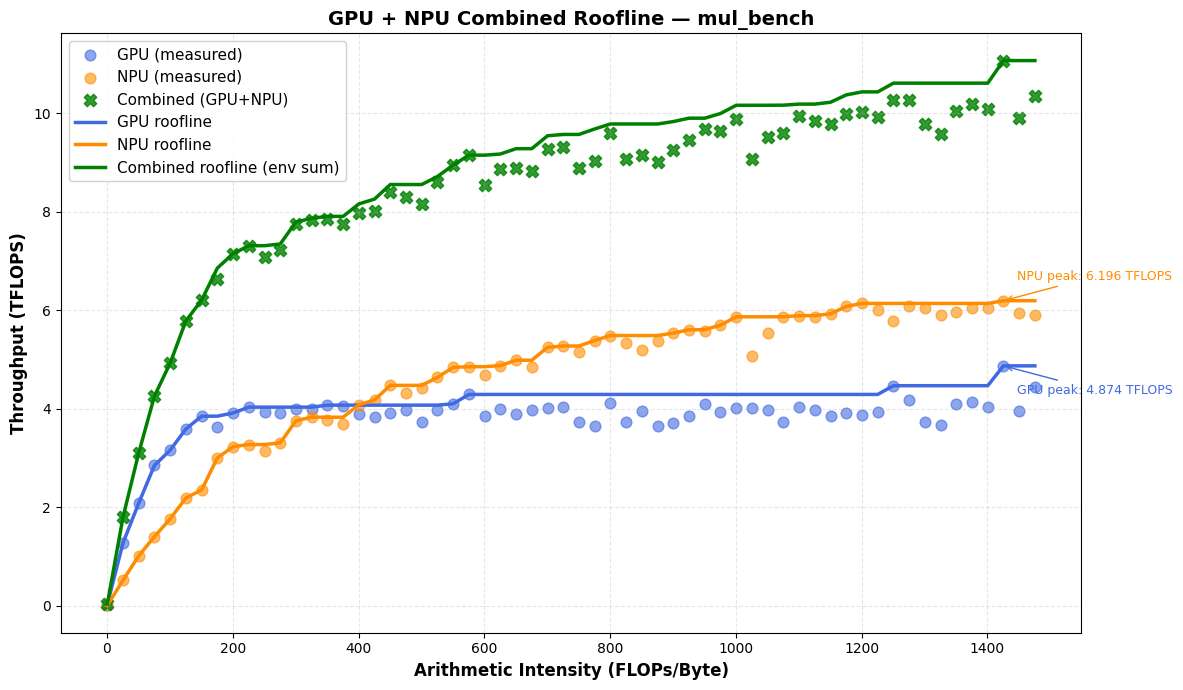

In [ ]:
# ── Plot ───────────────────────────────────────────────────────────────────────
gpu_ai     = np.array([p[0] for p in gpu_points])
gpu_tflops = np.array([p[1] for p in gpu_points])
npu_ai     = np.array([p[0] for p in npu_points])
npu_tflops = np.array([p[1] for p in npu_points])

def upper_envelope(ai, tflops):
    order = np.argsort(ai)
    return ai[order], np.maximum.accumulate(tflops[order])

gpu_env_ai, gpu_env = upper_envelope(gpu_ai,  gpu_tflops)
npu_env_ai, npu_env = upper_envelope(npu_ai,  npu_tflops)

fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(gpu_ai, gpu_tflops, s=60, alpha=0.6, color="royalblue",  label="GPU (measured)")
ax.scatter(npu_ai, npu_tflops, s=60, alpha=0.6, color="darkorange", label="NPU (measured)")
ax.scatter(
    [p[0] for p in combined_points if p[1] is not None and p[2] is not None],
    [p[1] + p[2] for p in combined_points if p[1] is not None and p[2] is not None],
    s=80, alpha=0.8, color="green", marker="X", label="Combined (GPU+NPU)"
)
ax.plot(gpu_env_ai, gpu_env, color="royalblue",  linewidth=2.5, label="GPU roofline")
ax.plot(npu_env_ai, npu_env, color="darkorange", linewidth=2.5, label="NPU roofline")
ax.plot(
    gpu_env_ai,
    gpu_env + np.interp(gpu_env_ai, npu_env_ai, npu_env, left=0, right=0),
    color="green", linewidth=2.5, label="Combined roofline (env sum)"
)
[68/534] R=  202  AI=101.00 FLOPs/Byte  NPU 2.2103 TFLOPS  NPU BW 21.88 GB/s

ax.set_xlabel("Arithmetic Intensity (FLOPs/Byte)", fontsize=12, fontweight="bold")
ax.set_ylabel("Throughput (TFLOPS)",               fontsize=12, fontweight="bold")
ax.set_title("GPU + NPU Combined Roofline — mul_bench", fontsize=14, fontweight="bold")
ax.grid(True, which="both", alpha=0.3, linestyle="--")
ax.legend(fontsize=11, framealpha=0.9)

if len(gpu_points):
    ax.annotate(
        f"GPU peak: {gpu_tflops.max():.3f} TFLOPS",
        xy=(gpu_ai[gpu_tflops.argmax()], gpu_tflops.max()),
        xytext=(10, -20), textcoords="offset points",
        fontsize=9, color="royalblue",
        arrowprops=dict(arrowstyle="->", color="royalblue"),
    )
if len(npu_points):
    ax.annotate(
        f"NPU peak: {npu_tflops.max():.3f} TFLOPS",
        xy=(npu_ai[npu_tflops.argmax()], npu_tflops.max()),
        xytext=(10, 15), textcoords="offset points",
        fontsize=9, color="darkorange",
        arrowprops=dict(arrowstyle="->", color="darkorange"),
    )

plt.tight_layout()
out_png = REPO_ROOT / "gpu_npu_combined_roofline.png"
plt.savefig(str(out_png), dpi=300, bbox_inches="tight")
print(f"Saved: {out_png}")
plt.show()

In [ ]:
# ── Config ────────────────────────────────────────────────────────────────────
gpu_points2      = []
npu_points2      = []
combined_points2 = []
model_points     = []


total_batches = 100
repeats      = 10

R_VALUES = list(range(1, 1601, 3))


In [243]:
R_VALUES = list(range(1, 3000, 1))

In [248]:
gpu_points2      = []
# ── GPU sweep ─────────────────────────────────────────────────────────────────
for idx, r in enumerate(R_VALUES):
    print(f"[{idx+1}/{len(R_VALUES)}] R={r:5d}  AI={r/2:.2f} FLOPs/Byte", end="  ", flush=True)
    try:
        datag = run_bench(r, iters_gpu=total_batches, run_gpu=True, run_npu=False, repeats=repeats)
        g = datag.get("gpu")
        if g:
            gpu_points2.append((g["arith_intensity"], g["tflops"]))
            print(f"GPU {g['tflops']:.4f} TFLOPS", end="  ", flush=True)
            print(f"GPU BW {g['bandwidth_gbps']:.2f} GB/s")
        else:#ax.plot([p[0] for p in model_points],[p[1] for p in model_points],color="purple", linewidth=2.5, label="Combined roofline (model)")
            print("no GPU result")
    except Exception as exc:
        print(f"FAILED: {exc}")

print(f"\nCollected {len(gpu_points2)} GPU points.")

[1/2999] R=    1  AI=0.50 FLOPs/Byte  GPU 0.0357 TFLOPS  GPU BW 71.36 GB/s
[2/2999] R=    2  AI=1.00 FLOPs/Byte  GPU 0.0684 TFLOPS  GPU BW 68.38 GB/s
[3/2999] R=    3  AI=1.50 FLOPs/Byte  GPU 0.1031 TFLOPS  GPU BW 68.71 GB/s
[4/2999] R=    4  AI=2.00 FLOPs/Byte  GPU 0.1446 TFLOPS  GPU BW 72.31 GB/s
[5/2999] R=    5  AI=2.50 FLOPs/Byte  GPU 0.1673 TFLOPS  GPU BW 66.92 GB/s
[6/2999] R=    6  AI=3.00 FLOPs/Byte  GPU 0.2102 TFLOPS  GPU BW 70.07 GB/s
[7/2999] R=    7  AI=3.50 FLOPs/Byte  GPU 0.2422 TFLOPS  GPU BW 69.19 GB/s
[8/2999] R=    8  AI=4.00 FLOPs/Byte  GPU 0.2800 TFLOPS  GPU BW 70.01 GB/s
[9/2999] R=    9  AI=4.50 FLOPs/Byte  GPU 0.3159 TFLOPS  GPU BW 70.20 GB/s
[10/2999] R=   10  AI=5.00 FLOPs/Byte  GPU 0.3531 TFLOPS  GPU BW 70.62 GB/s
[11/2999] R=   11  AI=5.50 FLOPs/Byte  GPU 0.4008 TFLOPS  GPU BW 72.88 GB/s
[12/2999] R=   12  AI=6.00 FLOPs/Byte  GPU 0.4406 TFLOPS  GPU BW 73.43 GB/s
[13/2999] R=   13  AI=6.50 FLOPs/Byte  GPU 0.4695 TFLOPS  GPU BW 72.24 GB/s
[14/2999] R=   14  AI

In [ ]:
npu_points      = []
# ── NPU sweep ─────────────────────────────────────────────────────────────────
for idx, r in enumerate(R_VALUES):
    print(f"[{idx+1}/{len(R_VALUES)}] R={r:5d}  AI={r/2:.2f} FLOPs/Byte", end="  ", flush=True)
    try:
        if RUN_NPU:
            ensure_npu_artifacts(r)
        datan = run_bench(r, iters_npu=total_batches, run_gpu=False, run_npu=True, repeats=repeats)
        n = datan.get("npu")
        if n:
            npu_points.append((n["arith_intensity"], n["tflops"]))

            print(f"NPU {n['tflops']:.4f} TFLOPS", end="  ", flush=True)
            print(f"NPU BW {n['bandwidth_gbps']:.2f} GB/s")
        else:
            print("no NPU result")
    except Exception as exc:
        print(f"FAILED: {exc}")

print(f"\nCollected {len(npu_points)} NPU points.")

[1/2999] R=    1  AI=0.50 FLOPs/Byte    Compiling NPU artifact for R=1... done
NPU 0.0147 TFLOPS  NPU BW 29.33 GB/s
[2/2999] R=    2  AI=1.00 FLOPs/Byte    Compiling NPU artifact for R=2... done
NPU 0.0293 TFLOPS  NPU BW 29.28 GB/s
[3/2999] R=    3  AI=1.50 FLOPs/Byte    Compiling NPU artifact for R=3... done
NPU 0.0444 TFLOPS  NPU BW 29.58 GB/s
[4/2999] R=    4  AI=2.00 FLOPs/Byte    Compiling NPU artifact for R=4... done
NPU 0.0595 TFLOPS  NPU BW 29.76 GB/s
[5/2999] R=    5  AI=2.50 FLOPs/Byte    Compiling NPU artifact for R=5... done
NPU 0.0731 TFLOPS  NPU BW 29.23 GB/s
[6/2999] R=    6  AI=3.00 FLOPs/Byte    Compiling NPU artifact for R=6... done
NPU 0.0870 TFLOPS  NPU BW 29.01 GB/s
[7/2999] R=    7  AI=3.50 FLOPs/Byte    Compiling NPU artifact for R=7... done
NPU 0.1018 TFLOPS  NPU BW 29.08 GB/s
[8/2999] R=    8  AI=4.00 FLOPs/Byte    Compiling NPU artifact for R=8... done
NPU 0.1169 TFLOPS  NPU BW 29.22 GB/s
[9/2999] R=    9  AI=4.50 FLOPs/Byte    Compiling NPU artifact for R=9..

In [250]:
# ── Combined sweep ────────────────────────────────────────────────────────────
npu_mem      = 29.5
gpu_mem      = 74.5
total_mem    = 74.5
npu_perf     = 5693.3
gpu_perf     = 7523.7
_total_mem = total_mem  # local copy — mutated per iteration like the original
combined_points2 = []
for idx, r in enumerate(R_VALUES):
    print(f"[{idx+1}/{len(R_VALUES)}] R={r:5d}  AI={r/2:.2f} FLOPs/Byte", end="  ", flush=True)
    try:
        ai       = r / 2
        gpu_need = min(gpu_perf / ai, gpu_mem)
        npu_need = min(npu_perf / ai, npu_mem)
        if gpu_need + npu_need < _total_mem:
            _total_mem = gpu_need + npu_need
        gpu_batches = int(total_batches * (gpu_need / _total_mem))
        npu_batches = total_batches - gpu_batches
        if npu_batches == 0:
            npu_batches = 1
            gpu_batches = total_batches - npu_batches
        model_points.append((ai, min(min(gpu_perf, gpu_mem * ai) + min(npu_perf, npu_mem * ai), _total_mem * ai) / 1000))
        if npu_batches == 0:
            data         = run_bench(r, iters_gpu=total_batches, run_npu=False, repeats=repeats)
            total_tflops = data.get("gpu", {}).get("tflops")
        else:
            data         = run_bench(r, iters_gpu=gpu_batches, iters_npu=npu_batches, repeats=repeats)
            total_tflops = data.get("combined_tflops")
        if total_tflops is not None:
            combined_points2.append((ai, total_tflops))
        print(f"Combined {total_tflops:.4f} TFLOPS" if total_tflops is not None else "no combined result", end ="  ", flush=True)
        print(f"Combined Bandwidth: {total_tflops*1000/ai:.2f} GB/s" if total_tflops is not None else "no combined result")
    except Exception as exc:
        print(f"FAILED: {exc}")

print(f"\nCollected {len(combined_points2)} combined points.")

[1/2999] R=    1  AI=0.50 FLOPs/Byte  Combined 0.0444 TFLOPS  Combined Bandwidth: 88.71 GB/s
[2/2999] R=    2  AI=1.00 FLOPs/Byte  Combined 0.0842 TFLOPS  Combined Bandwidth: 84.17 GB/s
[3/2999] R=    3  AI=1.50 FLOPs/Byte  Combined 0.1353 TFLOPS  Combined Bandwidth: 90.17 GB/s
[4/2999] R=    4  AI=2.00 FLOPs/Byte  Combined 0.1820 TFLOPS  Combined Bandwidth: 91.01 GB/s
[5/2999] R=    5  AI=2.50 FLOPs/Byte  Combined 0.2216 TFLOPS  Combined Bandwidth: 88.65 GB/s
[6/2999] R=    6  AI=3.00 FLOPs/Byte  Combined 0.2607 TFLOPS  Combined Bandwidth: 86.89 GB/s
[7/2999] R=    7  AI=3.50 FLOPs/Byte  Combined 0.3082 TFLOPS  Combined Bandwidth: 88.07 GB/s
[8/2999] R=    8  AI=4.00 FLOPs/Byte  Combined 0.3541 TFLOPS  Combined Bandwidth: 88.52 GB/s
[9/2999] R=    9  AI=4.50 FLOPs/Byte  Combined 0.3995 TFLOPS  Combined Bandwidth: 88.77 GB/s
[10/2999] R=   10  AI=5.00 FLOPs/Byte  Combined 0.4504 TFLOPS  Combined Bandwidth: 90.09 GB/s
[11/2999] R=   11  AI=5.50 FLOPs/Byte  Combined 0.4782 TFLOPS  Combin

In [253]:
# ── Plot ───────────────────────────────────────────────────────────────────────
gpu_ai     = np.array([p[0] for p in gpu_points2])
gpu_tflops = np.array([p[1] for p in gpu_points2])
npu_ai     = np.array([p[0] for p in npu_points2])
npu_tflops = np.array([p[1] for p in npu_points2])
comb_ai   = np.array([p[0] for p in combined_points2 if p[1] is not None])
comb_tflops = np.array([p[1] for p in combined_points2 if p[1] is not None])

def upper_envelope(ai, tflops):
    order = np.argsort(ai)
    return ai[order], np.maximum.accumulate(tflops[order])

gpu_env_ai, gpu_env = upper_envelope(gpu_ai,  gpu_tflops)
npu_env_ai, npu_env = upper_envelope(npu_ai,  npu_tflops)
comb_env_ai, comb_env = upper_envelope(comb_ai, comb_tflops)

gpu_roofline = np.minimum(gpu_perf, gpu_mem * gpu_env_ai) / 1000
npu_roofline = np.minimum(npu_perf, npu_mem * npu_env_ai) / 1000
comb_roofline = np.minimum(gpu_roofline + npu_roofline, total_mem * comb_env_ai / 1000)

fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(gpu_ai, gpu_tflops, s=6, alpha=0.6, color="royalblue",  label="GPU (measured)")
ax.scatter(npu_ai, npu_tflops, s=6, alpha=0.6, color="darkorange", label="NPU (measured)")
ax.scatter(comb_ai, comb_tflops, s=6, alpha=0.8, color="green", marker="X", label="Combined (GPU+NPU)")

#ax.plot(gpu_env_ai, gpu_env, color="royalblue",  linewidth=2.5, label="GPU roofline")
#ax.plot(npu_env_ai, npu_env, color="darkorange", linewidth=2.5, label="NPU roofline")
#ax.plot(comb_env_ai, comb_env, color="green", linewidth=2.5, label="Combined roofline (env sum)")
ax.plot(gpu_env_ai, gpu_roofline, color="royalblue",  linewidth=2.5, linestyle="--", label="GPU roofline (model)")
ax.plot(npu_env_ai, npu_roofline, color="darkorange", linewidth=2.5, linestyle="--", label="NPU roofline (model)")
ax.plot(comb_env_ai, comb_roofline, color="green", linewidth=2.5, linestyle="--", label="Combined roofline (model)")

ax.set_xlabel("Arithmetic Intensity (FLOPs/Byte)", fontsize=12, fontweight="bold")
ax.set_ylabel("Throughput (TFLOPS)",               fontsize=12, fontweight="bold")
ax.set_title("GPU + NPU Combined Roofline — mul_bench", fontsize=14, fontweight="bold")
ax.grid(True, which="both", alpha=0.3, linestyle="--")
ax.legend(fontsize=11, framealpha=0.9)

if len(gpu_points):
    ax.annotate(
        f"GPU peak: {gpu_tflops.max():.3f} TFLOPS",
        xy=(gpu_ai[gpu_tflops.argmax()], gpu_tflops.max()),
        xytext=(10, -20), textcoords="offset points",
        fontsize=9, color="royalblue",
        arrowprops=dict(arrowstyle="->", color="royalblue"),
    )
if len(npu_points):
    ax.annotate(
        f"NPU peak: {npu_tflops.max():.3f} TFLOPS",
        xy=(npu_ai[npu_tflops.argmax()], npu_tflops.max()),
        xytext=(10, 15), textcoords="offset points",
        fontsize=9, color="darkorange",
        arrowprops=dict(arrowstyle="->", color="darkorange"),
    )

plt.tight_layout()
out_png = REPO_ROOT / "gpu_npu_combined_roofline.png"
plt.savefig(str(out_png), dpi=300, bbox_inches="tight")
print(f"Saved: {out_png}")
plt.show()

ValueError: operands could not be broadcast together with shapes (2999,) (2972,) 

In [168]:
# ── Summary ────────────────────────────────────────────────────────────────────
if len(gpu_points):
    print("GPU summary:")
    print(f"  Peak TFLOPS:    {gpu_tflops.max():.4f}")
    print(f"  AI at peak:     {gpu_ai[gpu_tflops.argmax()]:.2f} FLOPs/Byte")
    print(f"  AI range:       {gpu_ai.min():.3f} – {gpu_ai.max():.3f}")
if len(npu_points):
    print("NPU summary:")
    print(f"  Peak TFLOPS:    {npu_tflops.max():.4f}")
    print(f"  AI at peak:     {npu_ai[npu_tflops.argmax()]:.2f} FLOPs/Byte")
    print(f"  AI range:       {npu_ai.min():.3f} – {npu_ai.max():.3f}")

GPU summary:
  Peak TFLOPS:    7.5237
  AI at peak:     727.00 FLOPs/Byte
  AI range:       0.500 – 800.000
NPU summary:
  Peak TFLOPS:    5.6933
  AI at peak:     799.00 FLOPs/Byte
  AI range:       0.500 – 800.000


In [ ]:
# ── Save data ──────────────────────────────────────────────────────────────────
out_data = {
    "config": {
        "size_gpu": SIZE_GPU,
        "size_npu": SIZE_NPU,
        "r_values": R_VALUES,
    },
    "gpu": [
        {"r": r, "arith_intensity": ai, "tflops": tf}
        for r, (ai, tf) in zip(R_VALUES[:len(gpu_points)], gpu_points)
    ],
    "npu": [
        {"r": r, "arith_intensity": ai, "tflops": tf}
        for r, (ai, tf) in zip(R_VALUES[:len(npu_points)], npu_points)
    ],
}
out_json = REPO_ROOT / "gpu_npu_roofline_data.json"
with open(str(out_json), "w") as f:
    json.dump(out_data, f, indent=2)
print(f"Saved: {out_json}")

In [ ]:
# ── Save sweep-2 data ──────────────────────────────────────────────────────────
out_data2 = {
    "config": {
        "size_gpu":      SIZE_GPU,
        "size_npu":      SIZE_NPU,
        "r_values":      R_VALUES,
        "npu_mem":       npu_mem,
        "gpu_mem":       gpu_mem,
        "npu_perf":      npu_perf,
        "gpu_perf":      gpu_perf,
        "total_batches": total_batches,
    },
    "gpu": [
        {"r": r, "arith_intensity": ai, "tflops": tf}
        for r, (ai, tf) in zip(R_VALUES[:len(gpu_points2)], gpu_points2)
    ],
    "npu": [
        {"r": r, "arith_intensity": ai, "tflops": tf}
        for r, (ai, tf) in zip(R_VALUES[:len(npu_points2)], npu_points2)
    ],
    "combined": [
        {"arith_intensity": ai, "gpu_tflops": g, "npu_tflops": n}
        for ai, g, n in combined_points2
    ],
    "model": [
        {"arith_intensity": ai, "tflops": tf}
        for ai, tf in model_points
    ],
}
out_json2 = REPO_ROOT / "gpu_npu_roofline_data_1_to_1600_step_3.json"
with open(str(out_json2), "w") as f:
    json.dump(out_data2, f, indent=2)
print(f"Saved: {out_json2}")

Saved: /home/steven/gpu_bench/IRON/gpu_npu_roofline_data2.json


Saved: /home/steven/gpu_bench/IRON/gpu_npu_roofline_smoothed.png


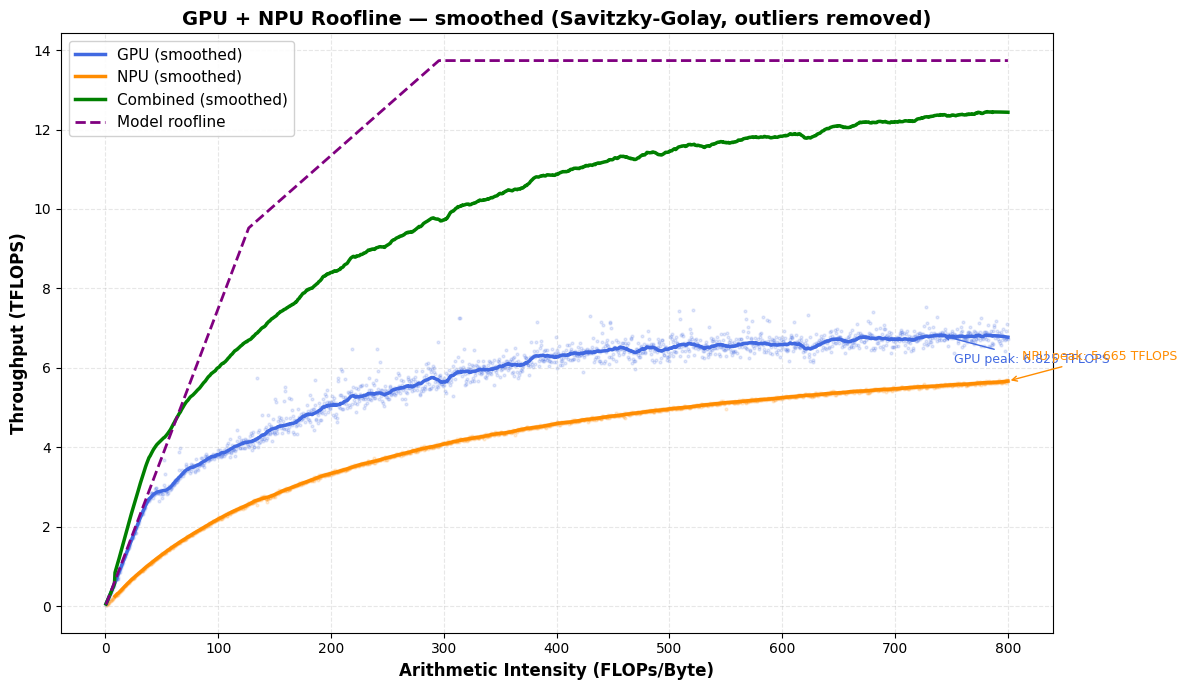

In [167]:
# ── Smoothing & outlier removal ────────────────────────────────────────────────
from scipy.ndimage import uniform_filter1d
from scipy.signal import savgol_filter

def remove_outliers_and_smooth(points, window=51, z_thresh=2.5, sg_polyorder=3):
    """
    Sort by AI, drop points whose tflops deviate > z_thresh std from a rolling
    median, then apply Savitzky-Golay smoothing to the survivors.
    Returns (ai_clean, tflops_smooth).
    """
    ai = np.array([p[0] for p in points])
    tf = np.array([p[1] for p in points])
    order = np.argsort(ai)
    ai, tf = ai[order], tf[order]

    half = window // 2
    rolling_med = np.array([
        np.median(tf[max(0, i - half):i + half + 1])
        for i in range(len(tf))
    ])
    sigma = (tf - rolling_med).std()
    mask  = np.abs(tf - rolling_med) < z_thresh * sigma
    ai_c, tf_c = ai[mask], tf[mask]

    sg_win = min(window, len(tf_c))
    if sg_win % 2 == 0:
        sg_win -= 1
    tf_s = savgol_filter(tf_c, window_length=sg_win, polyorder=sg_polyorder)
    return ai_c, tf_s

gpu_ai_s, gpu_tf_s = remove_outliers_and_smooth(gpu_points2, window=51, z_thresh=2.5)
npu_ai_s, npu_tf_s = remove_outliers_and_smooth(npu_points2, window=51, z_thresh=2.5)
comb_tf_s = gpu_tf_s + np.interp(gpu_ai_s, npu_ai_s, npu_tf_s, left=0, right=0)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

# Faint raw scatter
gpu_ai_raw = np.array([p[0] for p in gpu_points2])
gpu_tf_raw = np.array([p[1] for p in gpu_points2])
npu_ai_raw = np.array([p[0] for p in npu_points2])
npu_tf_raw = np.array([p[1] for p in npu_points2])
ax.scatter(gpu_ai_raw, gpu_tf_raw, s=4, alpha=0.15, color="royalblue")
ax.scatter(npu_ai_raw, npu_tf_raw, s=4, alpha=0.15, color="darkorange")

# Smoothed lines
ax.plot(gpu_ai_s, gpu_tf_s,  color="royalblue",  linewidth=2.5, label="GPU (smoothed)")
ax.plot(npu_ai_s, npu_tf_s,  color="darkorange", linewidth=2.5, label="NPU (smoothed)")
ax.plot(gpu_ai_s, comb_tf_s, color="green",       linewidth=2.5, label="Combined (smoothed)")

# Model roofline
if model_points:
    mp_ai = np.array([p[0] for p in model_points])
    mp_tf = np.array([p[1] for p in model_points])
    ax.plot(mp_ai, mp_tf, color="purple", linewidth=2, linestyle="--", label="Model roofline")

ax.set_xlabel("Arithmetic Intensity (FLOPs/Byte)", fontsize=12, fontweight="bold")
ax.set_ylabel("Throughput (TFLOPS)",               fontsize=12, fontweight="bold")
ax.set_title("GPU + NPU Roofline — smoothed (Savitzky-Golay, outliers removed)", fontsize=14, fontweight="bold")
ax.grid(True, which="both", alpha=0.3, linestyle="--")
ax.legend(fontsize=11, framealpha=0.9)

if len(gpu_ai_s):
    ax.annotate(
        f"GPU peak: {gpu_tf_s.max():.3f} TFLOPS",
        xy=(gpu_ai_s[gpu_tf_s.argmax()], gpu_tf_s.max()),
        xytext=(10, -20), textcoords="offset points",
        fontsize=9, color="royalblue",
        arrowprops=dict(arrowstyle="->", color="royalblue"),
    )
if len(npu_ai_s):
    ax.annotate(
        f"NPU peak: {npu_tf_s.max():.3f} TFLOPS",
        xy=(npu_ai_s[npu_tf_s.argmax()], npu_tf_s.max()),
        xytext=(10, 15), textcoords="offset points",
        fontsize=9, color="darkorange",
        arrowprops=dict(arrowstyle="->", color="darkorange"),
    )

plt.tight_layout()
out_png = REPO_ROOT / "gpu_npu_roofline_smoothed.png"
plt.savefig(str(out_png), dpi=300, bbox_inches="tight")
print(f"Saved: {out_png}")
plt.show()